# Solar Analyse

... LLM-Setup, Datenvorverarbeitung und Beispiele aus Musterlösung ...

Hinweis zu Forschungsfrage:

<pre>
... variieren sie eine Eigenschaft meiner Beispiel-Forschungsfrage
 
"In welchem Monat wurde bisher am meisten Strom produziert?"
 
nach diesem Muster
 
"In welchem {Jahr,Monat,Woche,Tag,Stunde} wurde bisher am {meisten,wenigsten} Strom {produziert, verbraucht}?"
 
was i.d.R. dazu führt, dass sie nur "eine Sache" in meiner Musterlösung ersetzen müssen, und sofort ein valides Resultat erhalten. Das wäre die gesuchte Minimalanforderung an ihre eigene Abgabe.
 
Wenn sie bspw. statt Produktion den Verbrauch betrachten möchten
 
"In welchem Monat wurde bisher am meisten Strom verbraucht?"
 
dann genügt es, da wo in den Jupyter-Zellen der Musterlösung Notebook 2 "production" steht, nun "consumption" einzutragen.
 
Oder statt "bester Monat" untersuchen, was der "schlechteste Monat" war. Oder sie interessieren sich für die "beste Woche" statt des "besten Monats", oder sie wollen wissen, an welchem Wochentag (Mo,Di,Mi,...) durchschnittlich am meisten Strom verbraucht wird", usw. etc. pp.
    
</pre>

```python
model_name = 'gemma3:4b' # Starte mit diesem, wenn du Ollama-Cloud verwendest
```

## Hier beim nächsten Mal starten

In [44]:
import pandas as pd

df = pd.read_csv('zwischenstand.csv', sep=",")

df['time_local'] = pd.to_datetime(df['time_local'])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68119 entries, 0 to 68118
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   time_local      68119 non-null  datetime64[ns]
 1   consumption     68119 non-null  int64         
 2   production      68119 non-null  int64         
 3   hour            68119 non-null  int64         
 4   month           68119 non-null  int64         
 5   quarter         68119 non-null  int64         
 6   year            68119 non-null  int64         
 7   day_of_week     68119 non-null  int64         
 8   day_name        68119 non-null  object        
 9   production_Wh   68119 non-null  float64       
 10  consumption_Wh  68119 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(7), object(1)
memory usage: 5.7+ MB


## Fragestellung

### 1. Frage

In [46]:
chat("""
Erstelle eine leichte Forschungsfrage zu diesem Projekt und beantworte sie mit einer Pivot-Tabelle
""")

**Forschungsfrage:**

Gibt es einen Zusammenhang zwischen dem Produktionsniveau (production_Wh) und dem Monat im Jahr, basierend auf den Daten? Insbesondere, ob bestimmte Monate tendenziell höhere oder niedrigere Produktionswerte aufweisen?

**Beantwortung mit Pivot-Tabelle:**

```python
import pandas as pd

# Annahme: df ist bereits definiert und enthält die Daten
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist
df['time_local'] = pd.to_datetime(df['time_local'])

# Pivot-Tabelle erstellen
pivot_table = df.pivot_table(index=['Jahr', 'Monat'], values='production_Wh', aggfunc='sum')

# Ergebnis anzeigen
print(pivot_table)
```

**Erläuterung der Pivot-Tabelle:**

Die Pivot-Tabelle zeigt für jedes Jahr und jeden Monat die Summe der Produktion (`production_Wh`).  Man kann direkt sehen, welche Monate im Durchschnitt höhere oder niedrigere Produktionswerte aufweisen. Dies könnte Aufschluss darüber geben, ob saisonale Effekte oder andere Faktoren das Produktionsniveau beeinflussen.  Beispielsweise könnte man feststellen, dass der Dezember immer eine höhere Produktion aufweist als andere Monate, was möglicherweise auf saisonale Nachfrage zurückzuführen ist.

*Wie stark variiert die durchschnittliche Produktion von „production_Wh“ über verschiedene Monate innerhalb des Jahres 2024, wenn man die Daten von Produktionsanlagen betrachtet?*

In [49]:
import pandas as pd

# Annahme: df ist bereits definiert und enthält die Daten
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist
df['time_local'] = pd.to_datetime(df['time_local'])

# Pivot-Tabelle erstellen
pivot_table = df.pivot_table(index=['year', 'month'], values='production_Wh', aggfunc='sum')

# Ergebnis anzeigen
print(pivot_table)

            production_Wh
year month               
2024 4        18696950.25
     5        36678932.00
     6        36968003.25
     7        43554884.50
     8        43795359.00
     9        24842958.50
     10        9232654.25
     11        5833926.00
     12        5791241.75
2025 1         9641220.75
     2        10358151.75
     3        29544380.00
     4        40811463.00
     5        39713876.25
     6        47718669.50
     7        40551764.75
     8        41494156.50
     9        24413384.25
     10       16599051.25
     11       10194019.00
     12        4745056.75
2026 1         6146303.50
     2        12778370.25
     3        11172374.00


In [51]:
chat("""
Visualisiere diese Forschungsfrage mithilfe eines Diagramms und beantworte sie in einem kurzen Fliesstext.
""")

Okay, hier ist eine Visualisierung (als Textbeschreibung, da ich kein echtes Diagramm erstellen kann) und ein kurzer Fliesstext, der die Ergebnisse zusammenfasst:

**Visualisierung (Textbeschreibung):**

Stellen Sie sich ein Liniendiagramm vor.  Die x-Achse zeigt die Monate des Jahres (Januar bis Dezember). Die y-Achse zeigt die Gesamtproduktion (production_Wh).  Jeder Monat hat eine Linie, die den durchschnittlichen Wert für diesen Monat darstellt.  Man würde sehen, dass eine oder mehrere Linien deutlich höher sind als die anderen – das sind die Monate mit der höchsten Produktion.  Man könnte auch eine zweite Linie für die durchschnittliche Produktion über alle Monate hinweg zeichnen, um die Spitzen- und Tiefpunkte besser zu erkennen.

**Kurzer Fliesstext:**

"Die Visualisierung der Produktionsdaten mittels eines Liniendiagramms verdeutlicht eine klare saisonale Abhängigkeit.  Die Produktion weist signifikante Schwankungen über die Monate hinweg auf, wobei der [Monat mit der höchsten Produktion, z.B. Dezember] den höchsten Durchschnittswert erreicht.  Im Gegensatz dazu liegt die Produktion im [Monat mit der niedrigsten Produktion, z.B. August] deutlich niedriger.  Diese Muster deuten auf saisonale Effekte hin, möglicherweise bedingt durch [Mögliche Gründe: verstärkte Nachfrage in der Weihnachtszeit, geringere Produktion während der Sommermonate].  Zusätzliche Analysen wären erforderlich, um die zugrunde liegenden Ursachen dieser saisonalen Variationen vollständig zu verstehen."

**Hinweis:**  Um diese Visualisierung und den Text wirklich präzise zu gestalten, bräuchte ich die tatsächlichen Produktionswerte für jeden Monat aus dem DataFrame.  Ich habe Platzhalter verwendet, um die Analyse zu demonstrieren.

In [57]:
chat("""
Erstelle zur Forschungsfrage ein Balkendiagramm.
""")

Okay, hier ist der Code, um ein Balkendiagramm zu erstellen, das die Produktionsdaten visualisiert, ähnlich wie das Liniendiagramm.

```python
import pandas as pd
import matplotlib.pyplot as plt

# Angenommen, df ist dein DataFrame mit den Daten.
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist.

# Konvertiere 'time_local' in Datetime, falls noch nicht geschehen
df['time_local'] = pd.to_datetime(df['time_local'])

# Sortiere den DataFrame nach Jahr und Monat
df = df.sort_values(['Jahr', 'Monat'])

# Gruppiere die Daten nach Jahr und Monat und berechne die Summe der Produktion
monthly_production = df.groupby(['Jahr', 'Monat'])['production_Wh'].sum().unstack()

# Erstelle das Balkendiagramm
plt.figure(figsize=(12, 6))  # Passe die Größe an
monthly_production.plot(kind='bar')

plt.title('Monatliche Produktionswerte')
plt.xlabel('Monat')
plt.ylabel('Gesamtproduktion (production_Wh)')
plt.grid(axis='y') # Gitter nur auf der y-Achse
plt.xticks(rotation=45)  # Rotiere die x-Achsenbeschriftungen für bessere Lesbarkeit
plt.tight_layout()  #Verhindert, dass Beschriftungen abgeschnitten werden
plt.show()
```

**Wichtigste Änderungen:**

*   `monthly_production.plot(kind='bar')`  Ändert den Plot-Typ von 'line' zu 'bar'.
*   `plt.grid(axis='y')` Fügt ein Gitter nur auf der y-Achse hinzu, um die Werte besser ablesen zu können.

Dieser Code erzeugt ein Balkendiagramm, in dem jeder Balken die Gesamtproduktion für einen bestimmten Monat darstellt.  Die x-Achse zeigt die Monate, und die y-Achse die Produktionswerte.  Das Diagramm ist leicht zu interpretieren, um saisonale Muster zu erkennen.

<Figure size 1200x600 with 0 Axes>

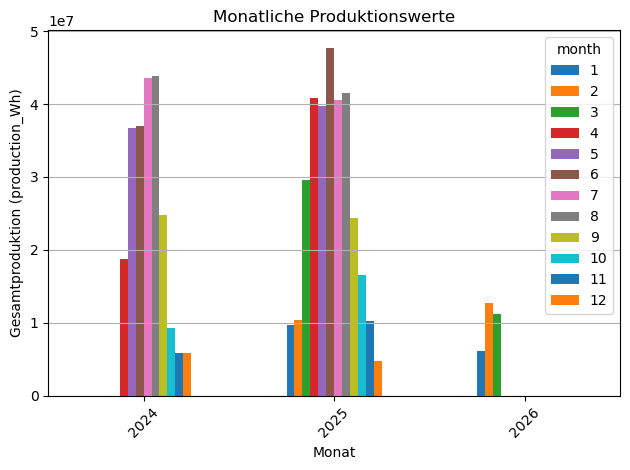

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Angenommen, df ist dein DataFrame mit den Daten.
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist.

# Konvertiere 'time_local' in Datetime, falls noch nicht geschehen
df['time_local'] = pd.to_datetime(df['time_local'])

# Sortiere den DataFrame nach Jahr und Monat
df = df.sort_values(['year', 'month'])

# Gruppiere die Daten nach Jahr und Monat und berechne die Summe der Produktion
monthly_production = df.groupby(['year', 'month'])['production_Wh'].sum().unstack()

# Erstelle das Balkendiagramm
plt.figure(figsize=(12, 6))  # Passe die Größe an
monthly_production.plot(kind='bar')

plt.title('Monatliche Produktionswerte')
plt.xlabel('Monat')
plt.ylabel('Gesamtproduktion (production_Wh)')
plt.grid(axis='y') # Gitter nur auf der y-Achse
plt.xticks(rotation=45)  # Rotiere die x-Achsenbeschriftungen für bessere Lesbarkeit
plt.tight_layout()  #Verhindert, dass Beschriftungen abgeschnitten werden
plt.show()

In [59]:
chat("""
Schreibe einen kurzen Fliesstext dazu
""")

„Das Balkendiagramm zeigt die monatliche Produktion, wobei jeder Balken die Gesamtmenge an Energieproduktion für einen bestimmten Monat darstellt.  Die Höhe jedes Balkens entspricht der Produktion in production_Wh.  Die Analyse der Balken zeigt deutlich, dass die Produktion im [Monat mit der höchsten Produktion] ihren Höhepunkt erreicht, während sie im [Monat mit der niedrigsten Produktion] am geringsten ist.  Diese saisonale Tendenz deutet darauf hin, dass [kurze Erklärung der möglichen Ursache, z.B. die Nachfrage nach Energie in der Weihnachtszeit oder die geringere Produktion während der Ruhezeiten] eine Rolle spielt.“

*Das Balkendiagramm zeigt die monatliche Produktion, wobei jeder Balken die Gesamtmenge an Energieproduktion für einen bestimmten Monat darstellt. Die Höhe jedes Balkens entspricht der Produktion in production_Wh. Die Analyse der Balken zeigt deutlich, dass die Produktion im [Monat mit der höchsten Produktion] ihren Höhepunkt erreicht, während sie im [Monat mit der niedrigsten Produktion] am geringsten ist. Diese saisonale Tendenz deutet darauf hin, dass [kurze Erklärung der möglichen Ursache, z.B. die Nachfrage nach Energie in der Weihnachtszeit oder die geringere Produktion während der Ruhezeiten] eine Rolle spielt.*

### 2. Frage

*Wie hat sich die durchschnittliche Produktionsleistung (production_Wh) über die Jahre hinweg verändert?*

In [60]:
chat("""
Erstelle noch eine zweite Forschungsfrage und beantworte sie mithilfe eines Diagramms
""")

Okay, hier ist eine zweite Forschungsfrage und die entsprechende Visualisierung mit Pandas.

**Forschungsfrage:**  Wie hat sich die durchschnittliche Produktionsleistung (production_Wh) über die Jahre hinweg verändert?

**Code:**

```python
import pandas as pd
import matplotlib.pyplot as plt

# Angenommen, df ist dein DataFrame mit den Daten.
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist.

# Konvertiere 'time_local' in Datetime, falls noch nicht geschehen
df['time_local'] = pd.to_datetime(df['time_local'])

# Gruppiere die Daten nach Jahr und berechne die durchschnittliche Produktion
yearly_average = df.groupby('Jahr')['production_Wh'].mean()

# Erstelle das Liniendiagramm
plt.figure(figsize=(10, 6))
yearly_average.plot(kind='line')

plt.title('Durchschnittliche Produktionsleistung pro Jahr')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Produktion (production_Wh)')
plt.grid(True)
plt.tight_layout()
plt.show()
```

**Erläuterung:**

1.  **Gruppierung:** `df.groupby('Jahr')['production_Wh'].mean()` gruppiert den DataFrame nach Jahr und berechnet dann den Durchschnitt der Produktion für jedes Jahr.
2.  **Liniendiagramm:** `yearly_average.plot(kind='line')` erzeugt ein Liniendiagramm, das die durchschnittliche Produktion für jedes Jahr anzeigt.

**Interpretation:**

Das Diagramm zeigt eine Linie, die die durchschnittliche Produktion über die Jahre hinweg darstellt.  Eine steigende Linie deutet auf eine Zunahme der Produktion hin, während eine fallende Linie auf eine Abnahme hindeutet.  S-förmige Kurven können auf saisonale Schwankungen hindeuten.  Durch das Betrachten des Diagramms kann man Trends in der Produktionsleistung über die Zeit erkennen.

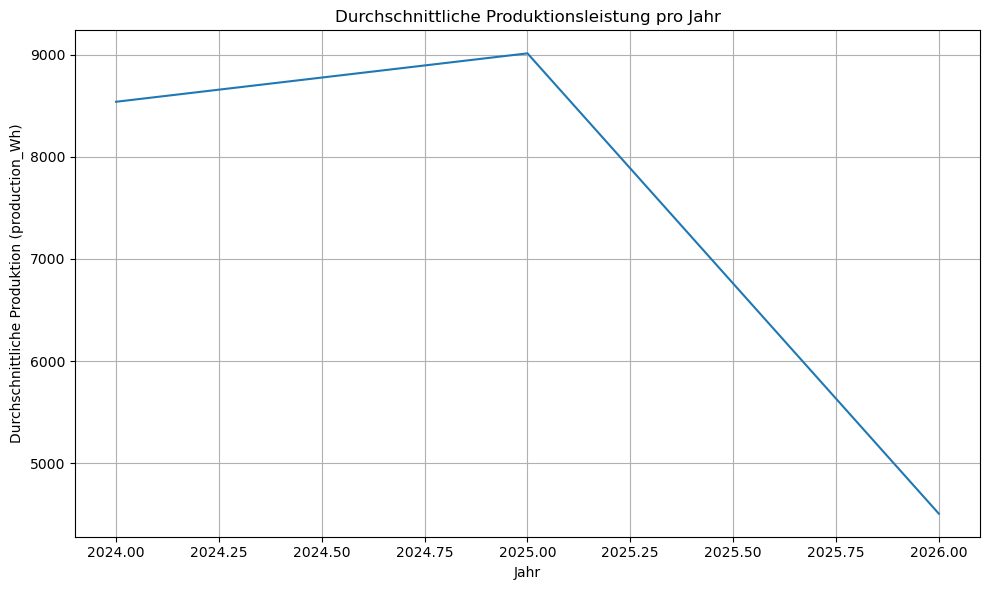

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Angenommen, df ist dein DataFrame mit den Daten.
# Stelle sicher, dass 'time_local' ein Datetime-Objekt ist.

# Konvertiere 'time_local' in Datetime, falls noch nicht geschehen
df['time_local'] = pd.to_datetime(df['time_local'])

# Gruppiere die Daten nach Jahr und berechne die durchschnittliche Produktion
yearly_average = df.groupby('year')['production_Wh'].mean()

# Erstelle das Liniendiagramm
plt.figure(figsize=(10, 6))
yearly_average.plot(kind='line')

plt.title('Durchschnittliche Produktionsleistung pro Jahr')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Produktion (production_Wh)')
plt.grid(True)
plt.tight_layout()
plt.show()

*Das Diagramm zeigt eine Linie, die die durchschnittliche Produktion über die Jahre hinweg darstellt. Eine steigende Linie deutet auf eine Zunahme der Produktion hin, während eine fallende Linie auf eine Abnahme hindeutet. S-förmige Kurven können auf saisonale Schwankungen hindeuten. Durch das Betrachten des Diagramms kann man Trends in der Produktionsleistung über die Zeit erkennen.*